# Spår A – Regression (förutsäga bostadsvärde)

## Bakgrundshistoria
En kund vill kunna göra grova värderingar av bostadsområden för att kunna planera investeringar och resurser. De vill kunna uppskatta bostadsvärdet baserat på områdets egenskaper.

## Uppdrag
Bygg en modell som förutsäger median_house_value.

## Syfte
Att kunna göra en rimlig värdeprognos och samtidigt förstå vilka faktorer som verkar hänga ihop med högre/lägre värde.

# Import

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyRegressor

from sklearn.metrics import confusion_matrix, classification_report, f1_score, mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


# Functions

In [14]:
def ev_model(y_true, y_pred, model_name: str) -> dict:
    """
    Utvärdera en baseline modell med flera vanliga mått.
    Returnerar en dict med RMSE, MAE, R2
    """
    rmse = root_mean_squared_error(y_true=y_true, y_pred=y_pred)
    mae = mean_absolute_error(y_true=y_true, y_pred=y_pred)
    r2 = r2_score(y_true=y_true, y_pred=y_pred)

    return {"model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

# 1) Dataförståelse & EDA 

## Data

In [15]:
file_path = "/housing.csv"
folder_path = "data"

df = pd.read_csv(folder_path + file_path)

print(df.info())
display(df.head())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Figure

<Axes: >

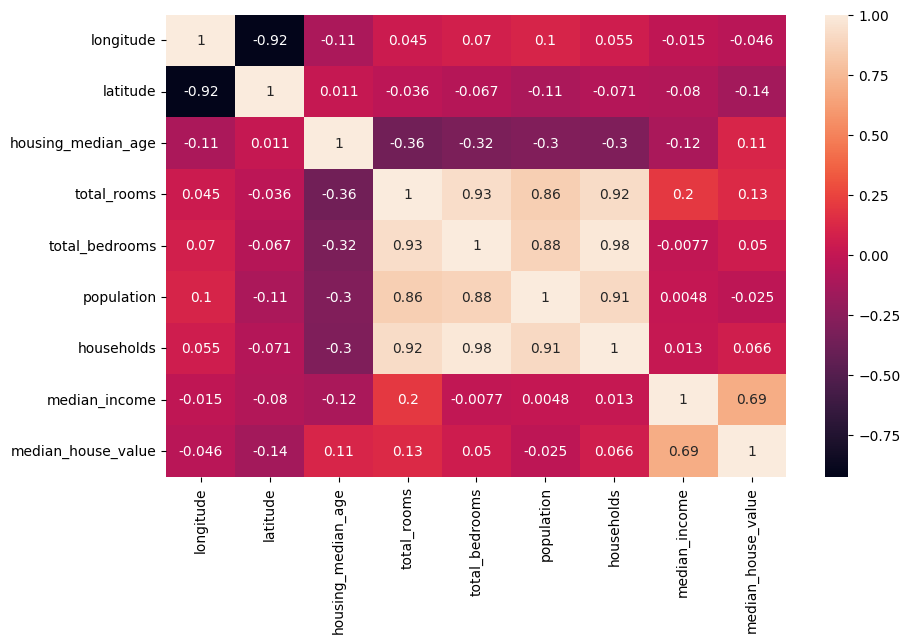

In [16]:
#Heat map

correlation_matrix = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, ax=ax)

## Heatmap Tolkning.

- Korrelationen mellan median_income och median_house_value ligger på ungefär 0.69, vilket innebär ett relativt starkt positivt samband.
- Den feature som har näst högst korrelation med median_house_value är total_rooms (≈0.13), vilket är ett svagt samband.

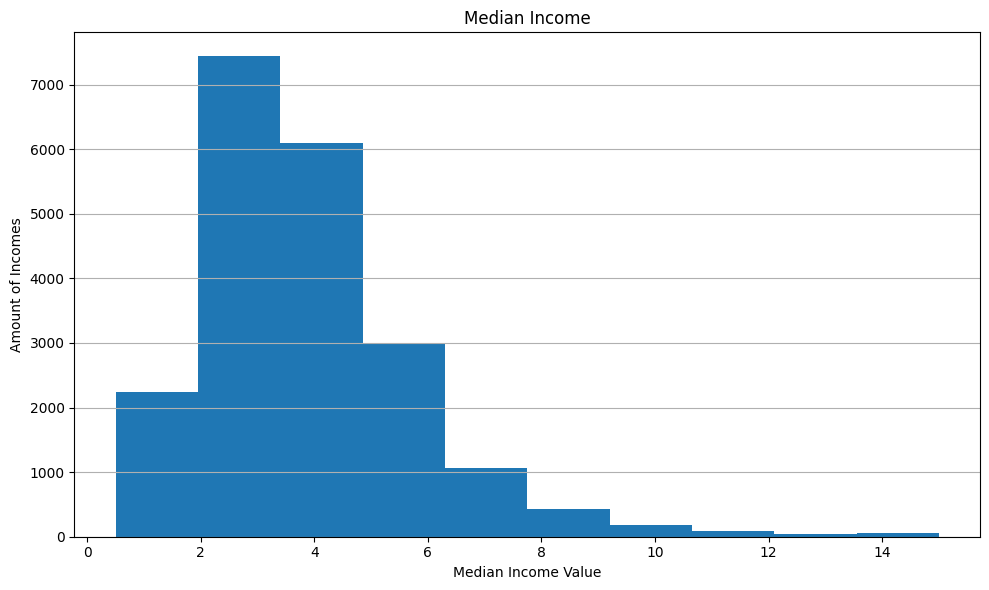

In [17]:
#Histogram

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(df["median_income"], bins=10)
ax.set_title("Median Income")
ax.set_xlabel("Median Income Value")
ax.set_ylabel("Amount of Incomes")
ax.grid(True, axis="y")
plt.tight_layout()


# Histogram på Median Income Tolkning

- Majoriteten av Incomes har en median_income mellan 2 och 5. Det finns även en del områden mellan 1 och 2 samt mellan 5 och 7, medan mycket få områden har median_income över 8.

# 2) Split + Preprocessing

In [18]:
target_name = "median_house_value"

X = df.drop(columns=[target_name])
y = df[target_name]

# make numeric/category feature
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["string"]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.30,
    random_state=42
)



In [19]:
print("X_Train : ", X_train.shape, "X_Test : ", X_test.shape)
print(f"\n{target_name} is important to have no missing values")
print("\nMissing Values (train)")
print(X_train.isna().sum().sort_values(ascending=False).head(10))
print("\nMissing Values (test)")
print(X_test.isna().sum().sort_values(ascending=False).head(10))
print("numeric_features :", numeric_features)
print("\ncategorical_features :", categorical_features)
print(X["ocean_proximity"].unique())

X_Train :  (14448, 9) X_Test :  (6192, 9)

median_house_value is important to have no missing values

Missing Values (train)
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

Missing Values (test)
total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64
numeric_features : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

categorical_features : ['ocean_proximity']
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


## Pipeline

In [30]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore", 
        sparse_output=True
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

logistic_regression_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500))
])

random_forest_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42

    ))
])



# 3) Modellering

## Baseline (DummyRegressor)

In [21]:
# Med en konversation med AI så sa den att datasetet var skevt så mitt val av strategy"median" var 
# bättre än att ta mean. så med dens förklaring att median är bättre för skev data och tack vare
# att hist av median_income var skev så tar jag median som strategy.
baseline_model_median = DummyRegressor(strategy="median")

baseline_model_median.fit(X_train, y_train)

baseline_pred_median = baseline_model_median.predict(X_test)

baseline_results_median = ev_model(
    y_true=y_test,
    y_pred=baseline_pred_median,
    model_name="Baseline (median)"
)

baseline_model_mean = DummyRegressor(strategy="mean")

baseline_model_mean.fit(X_train, y_train)

baseline_pred_mean = baseline_model_mean.predict(X_test)

baseline_results_mean = ev_model(
    y_true=y_test,
    y_pred=baseline_pred_mean,
    model_name="Baseline (mean)"
)

print(baseline_results_median)
print(baseline_results_mean)


{'model': 'Baseline (median)', 'RMSE': 117796.37732391812, 'MAE': 87932.6996124031, 'R2': -0.057185714023658685}
{'model': 'Baseline (mean)', 'RMSE': 114566.36798696463, 'MAE': 90620.0749174264, 'R2': -3.930972139798428e-06}


## LogisticRegression

In [32]:
logistic_regression_pipeline.fit(X_train, y_train)

log_pred = logistic_regression_pipeline.predict(X_test)

log_ev = ev_model(
    y_true=y_test,
    y_pred=log_pred,
    model_name="LogisticRegression"
)
print(log_ev)

{'model': 'LogisticRegression', 'RMSE': 145959.72270138958, 'MAE': 103355.34625322997, 'R2': -0.6231306399124363}


## RandomForestClassifier

In [31]:
random_forest_pipeline.fit(X_train, y_train)

rf_pred = random_forest_pipeline.predict(X_test)

rf_ev = ev_model(
    y_true=y_test,
    y_pred=rf_pred,
    model_name="RandomForest"
)
print(rf_ev)

{'model': 'RandomForest', 'RMSE': 140366.85633385446, 'MAE': 93891.54505813954, 'R2': -0.5011239839265222}
